Benchmarking Routine for Skills Project: Phase 2 <br>
Written by: Robert Methven (@methvenr) <br>
Date: April 2025 <br>

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import os
import uuid
from pathlib import Path

In [2]:
    def calculate_z_scores(self, metrics):
        """Calculate z-scores for specified metrics"""
        z_scores_dict = {}
        
        for metric in metrics:
            z_scores_dict[f'{metric}_z_score'] = stats.zscore(self.df[metric])
            
        self.z_scores = pd.DataFrame(z_scores_dict)
        self.df = pd.concat([self.df, self.z_scores], axis=1)

        ## Add MAD to here for skewed data: see below 

In [3]:
class SalesPerformanceBenchmark:
    def __init__(self):
        self.df = None
        self.z_scores = None
        self.performance_categories = None

    def load_data(self, file_path):
        """Load sales data from CSV"""
        try:
            self.df = pd.read_csv(file_path)
            return True
        except Exception as e:
            print(f"Error loading data: {e}")
            return False
    
    def calculate_z_scores(self, metrics):
        """
        Calculate z-scores for specified metrics with automatic skewness assessment
        and appropriate transformations
        """
        z_scores_dict = {}
        transformations_applied = {}
    
        def modified_zscore(x):
            """Calculate modified z-scores using median and MAD"""
            median = np.median(x)
            mad = stats.median_abs_deviation(x)
            if mad == 0:
                mad = np.mean(abs(x - median))  # Fallback if MAD is zero
            return 0.6745 * (x - median) / mad

        for metric in metrics:
            data = self.df[metric]
            skewness = stats.skew(data)
        
            # Initialize transformed data
            transformed_data = data.copy()
            transformation_type = "None"
        
            # Decision tree for transformations based on skewness
            if abs(skewness) < 0.5:
                # Nearly symmetric - use standard z-scores
                z_scores = stats.zscore(data)
                transformation_type = "Standard"
            
            elif abs(skewness) >= 0.5 and abs(skewness) < 1:
                # Moderately skewed - use modified z-scores
                z_scores = modified_zscore(data)
                transformation_type = "Modified z-score"
            
            else:
                # Heavily skewed - attempt transformations
                if skewness > 0:  # Right-skewed
                    if np.all(data > 0):
                        # Try log transformation
                        transformed_data = np.log1p(data)  # log1p handles zero values
                        transformation_type = "Log"
                    else:
                        # Try square root with sign preservation
                        transformed_data = np.sign(data) * np.sqrt(np.abs(data))
                        transformation_type = "Signed square root"
                else:  # Left-skewed
                    # Try square transformation
                    transformed_data = np.sign(data) * (np.abs(data) ** 2)
                    transformation_type = "Square"
            
                # Check if transformation improved skewness
                new_skewness = stats.skew(transformed_data)
                if abs(new_skewness) < abs(skewness):
                    z_scores = stats.zscore(transformed_data)
                else:
                    # If transformation didn't help, use modified z-scores
                    z_scores = modified_zscore(data)
                    transformation_type = "Modified z-score (heavy skew)"
        
            # Store results
            z_scores_dict[f'{metric}_z_score'] = z_scores
            transformations_applied[metric] = {
                'original_skewness': skewness,
                'transformation': transformation_type
            }
    
        # Create DataFrame with z-scores
        self.z_scores = pd.DataFrame(z_scores_dict)
    
        # Add z-scores to original DataFrame
        self.df = pd.concat([self.df, self.z_scores], axis=1)
    
        # Store transformation information
        self.transformations = transformations_applied
    
        # Optional: Print transformation summary
        print("\nTransformation Summary:")
        for metric, info in transformations_applied.items():
            print(f"{metric}:")
            print(f"  Skewness: {info['original_skewness']:.3f}")
            print(f"  Transformation: {info['transformation']}")
            
    def categorize_performance(self, z_score_threshold=1):
        """
        Categorize performance based on z-scores, excluding null values from average calculation.
    
        Args:
            z_score_threshold (float): The threshold value for categorizing performance (default=1)
    
        Returns:
            None: Updates self.df with new 'performance_category' column
    
        Categories:
            - Top Performer: avg z-score >= threshold
            - Core Performer: -threshold < avg z-score < threshold
            - Growth Opportunity: avg z-score <= -threshold
        """
        # Input validation
        if not isinstance(z_score_threshold, (int, float)):
            raise TypeError("z_score_threshold must be a number")
        if z_score_threshold <= 0:
            raise ValueError("z_score_threshold must be positive")
    
        # Calculate mean z-scores excluding NaN values
        avg_z_scores = self.z_scores.mean(axis=1, skipna=True)
    
        # Create categories using numpy.where for better performance
        conditions = [
            (avg_z_scores >= z_score_threshold),
            (avg_z_scores <= -z_score_threshold)
        ]
        choices = ['Top Performer', 'Growth Opportunity']
        self.df['performance_category'] = np.select(
            conditions, 
            choices,
            default='Core Performer'
        )

    def generate_summary_stats(self):
        """Generate summary statistics"""
        summary = {}
        
        # Basic statistics for each metric
        summary['basic_stats'] = self.df.describe()
        
        # Performance category distribution
        summary['category_distribution'] = self.df['performance_category'].value_counts()
        
        return summary
    
    def visualize_performance(self, title=None):  # Added title parameter with default None
        """Create visualizations"""
        # Distribution plot
        plt.figure(figsize=(15, 10))
    
        # Plot 1: Z-score distribution
        plt.subplot(2, 1, 1)
        for col in self.z_scores.columns:
            sns.kdeplot(data=self.df[col], label=col)
    
        # Use custom title if provided, otherwise use default
        if title:
            plt.suptitle(title, fontsize=16)
            plt.title('Z-Score Distribution by Metric', pad=20)
        else:
            plt.title('Z-Score Distribution by Metric')
        plt.legend()
    
        # Plot 2: Performance categories
        plt.subplot(2, 1, 2)
        sns.countplot(data=self.df, x='performance_category')
        plt.title('Performance Category Distribution')
    
        plt.tight_layout()
        plt.show()

    def export_results(self, output_path):
        """Export results to CSV"""
        self.df.to_csv(output_path, index=False)

## Import, Process & Prepare Data

In [4]:
# Import metrics data
input_metrics = pd.read_excel("benchmarking/input_metrics/input_metrics.xlsx")

# Import cluster data
clusters = pd.read_excel("benchmarking/input_metrics/clusters.xlsx")

# Import original sfdc data
sfdc = pd.read_excel("benchmarking/input_metrics/sfdc_data.xlsx")

## Pivot metrics data

In [5]:
# Create a pivot function for metrics data
def pivot_skills_metrics(df):
    """
    Pivot a DataFrame with emplid, skill, and metric_value columns.
    emplid becomes the primary key (index),
    skills become columns,
    metric_values become the values in the table.
    
    Parameters:
    df: DataFrame with columns ['emplid', 'skill', 'metric_value']
    
    Returns:
    Pivoted DataFrame
    """
    # Pivot the DataFrame
    pivoted_df = df.pivot(
        index='emplid',
        columns='skill',
        values='metric_value'
    )
    
    # Fill NaN values with 0
    pivoted_metrics = pivoted_df.fillna(0)
    
    # Reset index to make emplid a column
    pivoted_metrics.reset_index(inplace=True)
    
    return pivoted_metrics

In [6]:
# Pivot the DataFrame
metrics = pivot_skills_metrics(input_metrics)

In [7]:
# Merge metrics and cluster data
cluster_metrics_df = metrics.merge(
        clusters,
        on='emplid',
        how='inner'
    )

# Remove / from string
cluster_metrics_df['custom_smsrole'] = cluster_metrics_df['custom_smsrole'].str.replace('/', ' ')

In [8]:
# Perform the join operation
cluster_metrics_df = pd.merge(
    cluster_metrics_df,
    sfdc[['emplid', 'tenure', 'segment', 'geo','job_lvl_sort']],
    on='emplid',
    how='left'
)

## Process Data

In [9]:
# Function to create data frames by job role and cluster for analysis
def process_df(df):

    # Split the dataframe by job_role
    job_role_groups = df.groupby('custom_smsrole')

    # Initialize a list to store the resulting dataframes
    result_dataframes = []

    # Iterate through each job_role group
    for job_role, job_df in job_role_groups:
        # Split the job_role dataframe by cluster
        cluster_groups = job_df.groupby('Cluster')

        # Iterate through each cluster group
        for cluster, cluster_df in cluster_groups:
            # Create a name for the dataframe
            df_name = f"{job_role}_{cluster}"

            # Add the dataframe to the result list with its name
            result_dataframes.append((df_name, cluster_df))

    return result_dataframes

In [10]:
# Run function to create data frames by job role and cluster for analysis

# use actual data
result = process_df(cluster_metrics_df)

# Use synthetic data
#result = process_df(synthetic_df) ############ replace with actual data after testing is complete

# Print the names of the resulting dataframes
for df_name, df in result:
    print(f"Dataframe: {df_name}, Shape: {df.shape}")

Dataframe: AM_0, Shape: (1752, 23)
Dataframe: AM_1, Shape: (974, 23)
Dataframe: AM_2, Shape: (674, 23)
Dataframe: AM_3, Shape: (2132, 23)
Dataframe: DGR_0, Shape: (235, 23)
Dataframe: DGR_1, Shape: (475, 23)
Dataframe: DGR_2, Shape: (119, 23)
Dataframe: DGR_3, Shape: (68, 23)
Dataframe: ISR_0, Shape: (223, 23)
Dataframe: ISR_1, Shape: (680, 23)
Dataframe: ISR_2, Shape: (250, 23)


In [11]:
# Create the benchmarking directory if it doesn't exist
os.makedirs('benchmarking dataframes', exist_ok=True)

# Export each DataFrame to CSV in the benchmarking folder
for name, df in result:
    file_path = os.path.join('benchmarking dataframes', f'{name}.csv')
    df.to_csv(file_path, index=False)
    print(f'Exported {file_path}')

Exported benchmarking dataframes\AM_0.csv
Exported benchmarking dataframes\AM_1.csv
Exported benchmarking dataframes\AM_2.csv
Exported benchmarking dataframes\AM_3.csv
Exported benchmarking dataframes\DGR_0.csv
Exported benchmarking dataframes\DGR_1.csv
Exported benchmarking dataframes\DGR_2.csv
Exported benchmarking dataframes\DGR_3.csv
Exported benchmarking dataframes\ISR_0.csv
Exported benchmarking dataframes\ISR_1.csv
Exported benchmarking dataframes\ISR_2.csv


In [12]:
for name, df in result:
    if 'custom_smsrole' in df.columns:
        # Define column lists for each role
        am_columns = [
            'emplid',
            'custom_smsrole',
            'Cluster',
            'tenure',
            'geo',
            'segment',
            'job_lvl_sort',
            'Strategy',
            'GenAI',
            'Industry Knowledge',
            'Communication',
            'Prospecting',
            'Problem Solving',
            'MEDPICC',
            'Process',
            'Project Management'
        ]

        dgr_columns = [
            'emplid',
            'custom_smsrole',
            'Cluster',
            'tenure',
            'geo',
            'segment',
            'job_lvl_sort',
            'Executive POV',
            'Prospecting',
            'MEDPICC',
            'Lead Management',
            'GenAI',
            'Collaboration'
        ]

        isr_columns = [
            'emplid',
            'custom_smsrole',
            'Cluster',
            'tenure',
            'geo',
            'segment',
            'job_lvl_sort',
            'Prospecting',
            'GenAI',
            'Account Management',
            'MEDPICC',
            'Technology',
            'Sales Skills',
            'Customer Engagement'
        ]

        # Handle AM roles
        if df['custom_smsrole'].eq('AM').any():
            am_df = df[df['custom_smsrole'] == 'AM'][am_columns]
            file_name = f'{name}_AM.csv'
            am_df.to_csv(f'benchmarking/{file_name}', index=False)
            print(f'Exported {file_name}')

        # Handle DGR roles
        if df['custom_smsrole'].eq('DGR').any():
            dgr_df = df[df['custom_smsrole'] == 'DGR'][dgr_columns]
            file_name = f'{name}_DGR.csv'
            dgr_df.to_csv(f'benchmarking/{file_name}', index=False)
            print(f'Exported {file_name}')

        # Handle ISR roles
        if df['custom_smsrole'].eq('ISR').any():
            isr_df = df[df['custom_smsrole'] == 'ISR'][isr_columns]
            file_name = f'{name}_ISR.csv'
            isr_df.to_csv(f'benchmarking/{file_name}', index=False)
            print(f'Exported {file_name}')

    else:
        # If custom_smsrole column doesn't exist, export original DataFrame
        file_name = f'{name}.csv'
        df.to_csv(file_name, index=False)
        print(f'Exported {file_name}')


Exported AM_0_AM.csv
Exported AM_1_AM.csv
Exported AM_2_AM.csv
Exported AM_3_AM.csv
Exported DGR_0_DGR.csv
Exported DGR_1_DGR.csv
Exported DGR_2_DGR.csv
Exported DGR_3_DGR.csv
Exported ISR_0_ISR.csv
Exported ISR_1_ISR.csv
Exported ISR_2_ISR.csv


## Run Benchmarking


Processing AM_0_AM.csv...

Transformation Summary:
Strategy:
  Skewness: 8.760
  Transformation: Signed square root
GenAI:
  Skewness: 0.850
  Transformation: Modified z-score
Industry Knowledge:
  Skewness: 37.669
  Transformation: Signed square root
Communication:
  Skewness: 41.821
  Transformation: Modified z-score (heavy skew)
Prospecting:
  Skewness: 4.611
  Transformation: Signed square root
Problem Solving:
  Skewness: 38.247
  Transformation: Signed square root
MEDPICC:
  Skewness: 0.571
  Transformation: Modified z-score
Process:
  Skewness: -3.304
  Transformation: Square
Project Management:
  Skewness: 32.892
  Transformation: Signed square root

Summary Statistics for AM_0_AM:
             emplid  Cluster  job_lvl_sort     Strategy        GenAI  \
count  1.752000e+03   1752.0   1752.000000  1752.000000  1752.000000   
mean   1.100754e+08      0.0      5.937785     0.030251     4.335046   
std    2.089722e+07      0.0      0.749726     0.218238     2.860185   
min    5.585

C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be rem

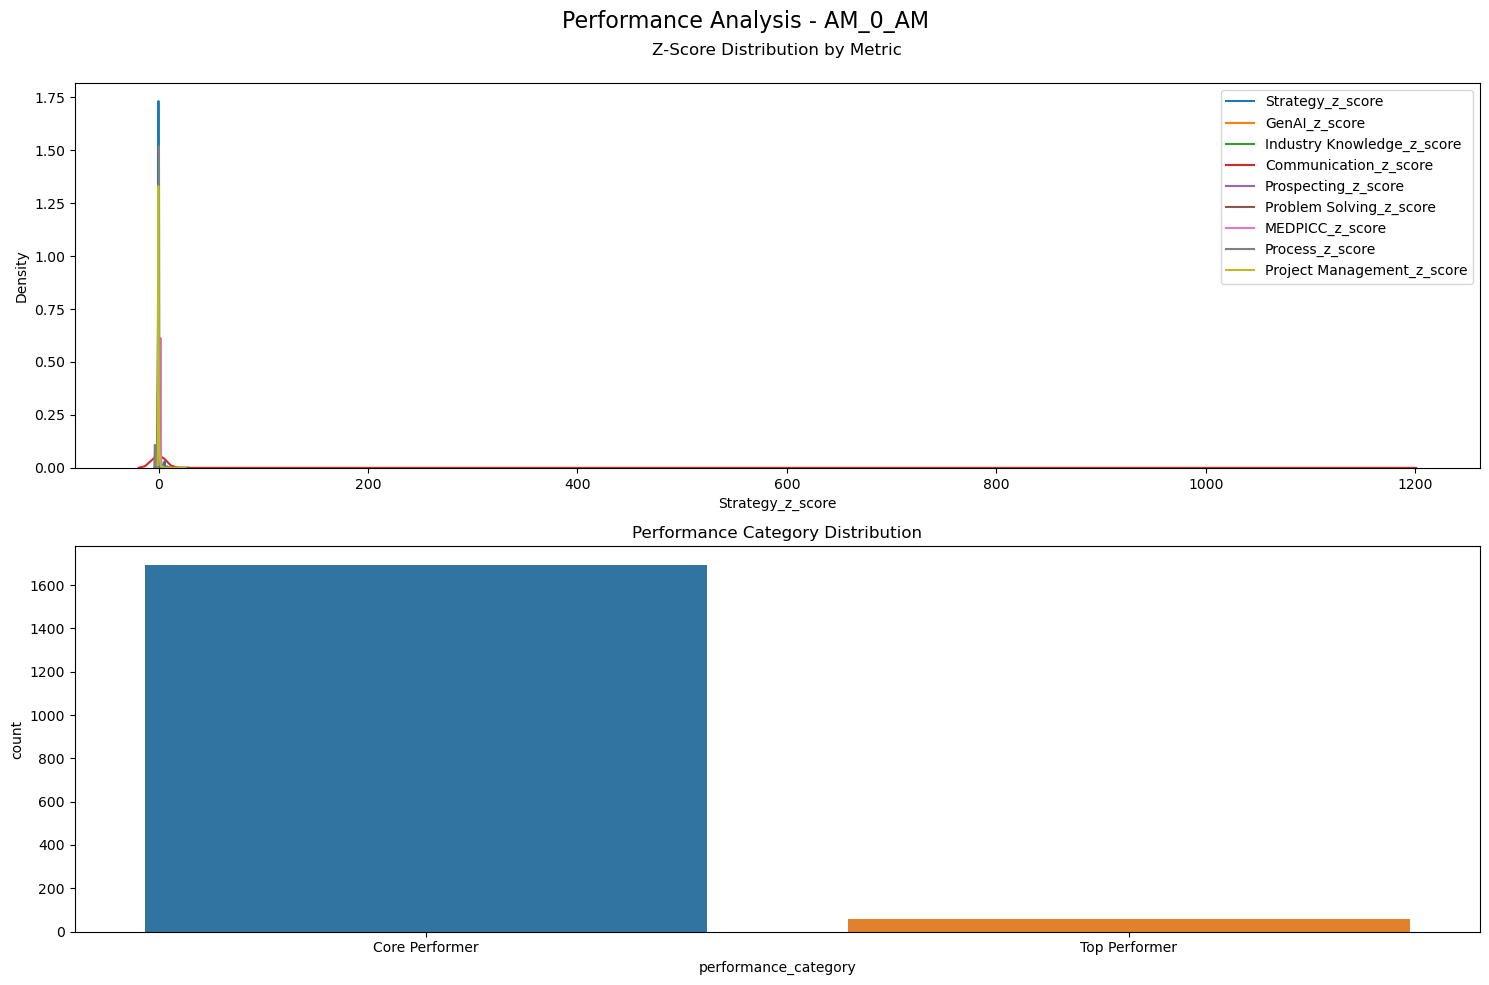

Results exported to: z_scores_original/results_AM_0_AM.csv
--------------------------------------------------------------------------------

Processing AM_1_AM.csv...

Transformation Summary:
Strategy:
  Skewness: 11.188
  Transformation: Signed square root
GenAI:
  Skewness: 1.576
  Transformation: Signed square root
Industry Knowledge:
  Skewness: 30.345
  Transformation: Signed square root
Communication:
  Skewness: 31.161
  Transformation: Modified z-score (heavy skew)
Prospecting:
  Skewness: 3.813
  Transformation: Signed square root
Problem Solving:
  Skewness: 30.047
  Transformation: Signed square root
MEDPICC:
  Skewness: 0.932
  Transformation: Modified z-score
Process:
  Skewness: -1.088
  Transformation: Square
Project Management:
  Skewness: 20.931
  Transformation: Signed square root

Summary Statistics for AM_1_AM:
             emplid  Cluster  job_lvl_sort    Strategy       GenAI  \
count  9.740000e+02    974.0    974.000000  974.000000  974.000000   
mean   1.553463e+

C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be rem

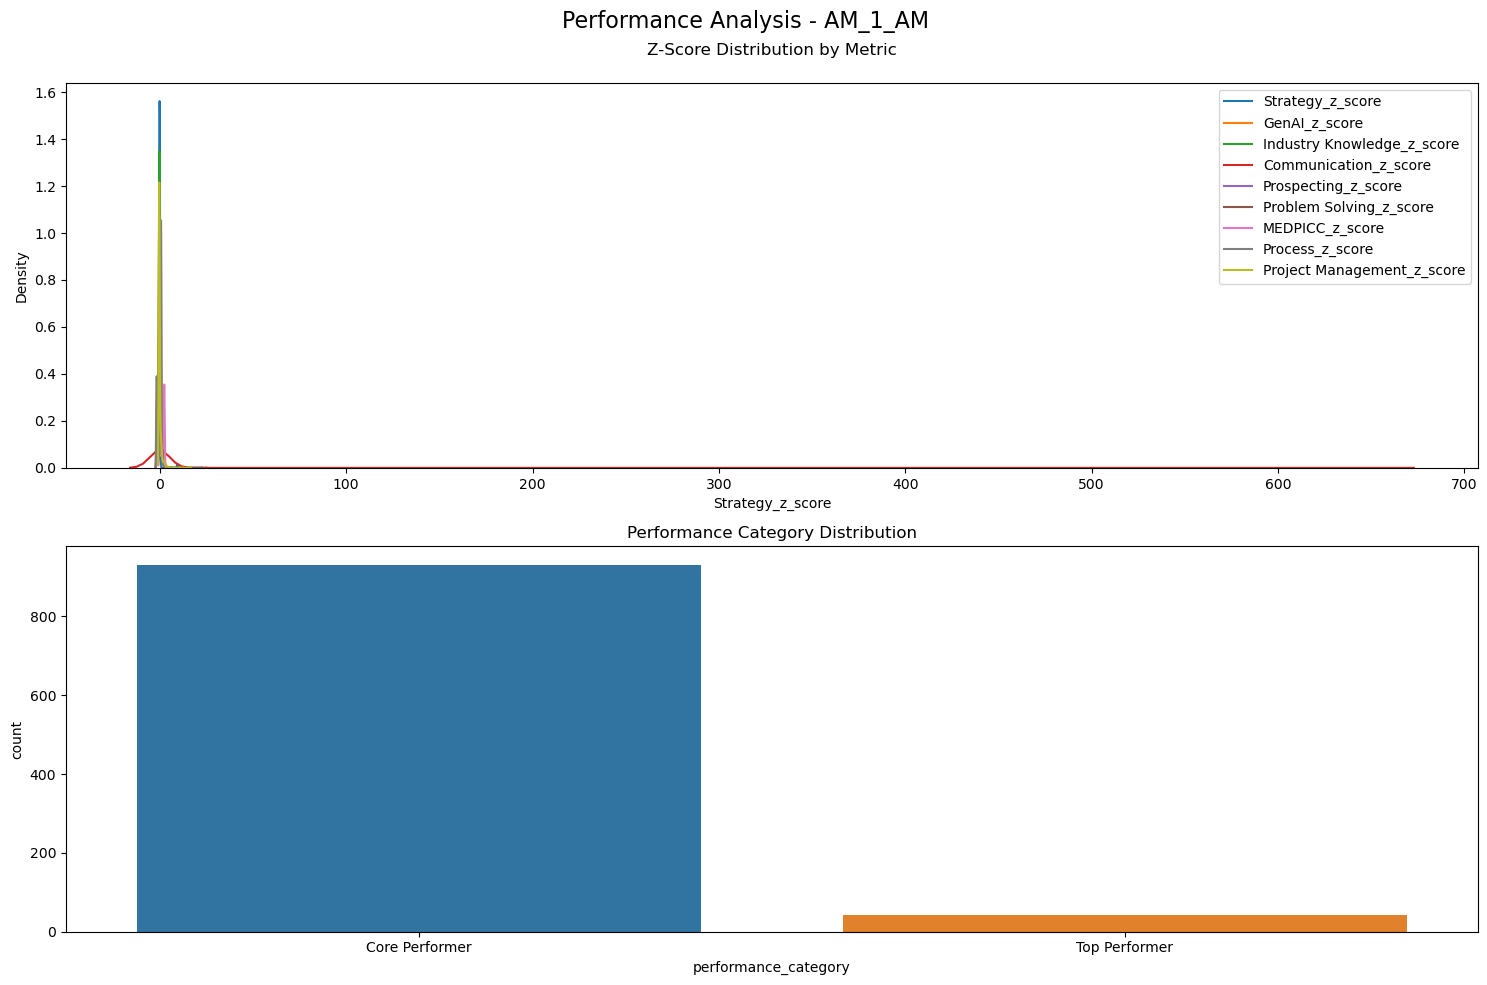

Results exported to: z_scores_original/results_AM_1_AM.csv
--------------------------------------------------------------------------------

Processing AM_2_AM.csv...

Transformation Summary:
Strategy:
  Skewness: 13.142
  Transformation: Signed square root
GenAI:
  Skewness: 0.737
  Transformation: Modified z-score
Industry Knowledge:
  Skewness: 12.395
  Transformation: Signed square root
Communication:
  Skewness: 25.904
  Transformation: Modified z-score (heavy skew)
Prospecting:
  Skewness: 5.636
  Transformation: Signed square root
Problem Solving:
  Skewness: 10.492
  Transformation: Signed square root
MEDPICC:
  Skewness: -0.690
  Transformation: Modified z-score
Process:
  Skewness: -7.572
  Transformation: Square
Project Management:
  Skewness: 18.144
  Transformation: Signed square root

Summary Statistics for AM_2_AM:
             emplid  Cluster  job_lvl_sort    Strategy       GenAI  \
count  6.740000e+02    674.0    674.000000  674.000000  674.000000   
mean   1.107174e+0

C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be rem

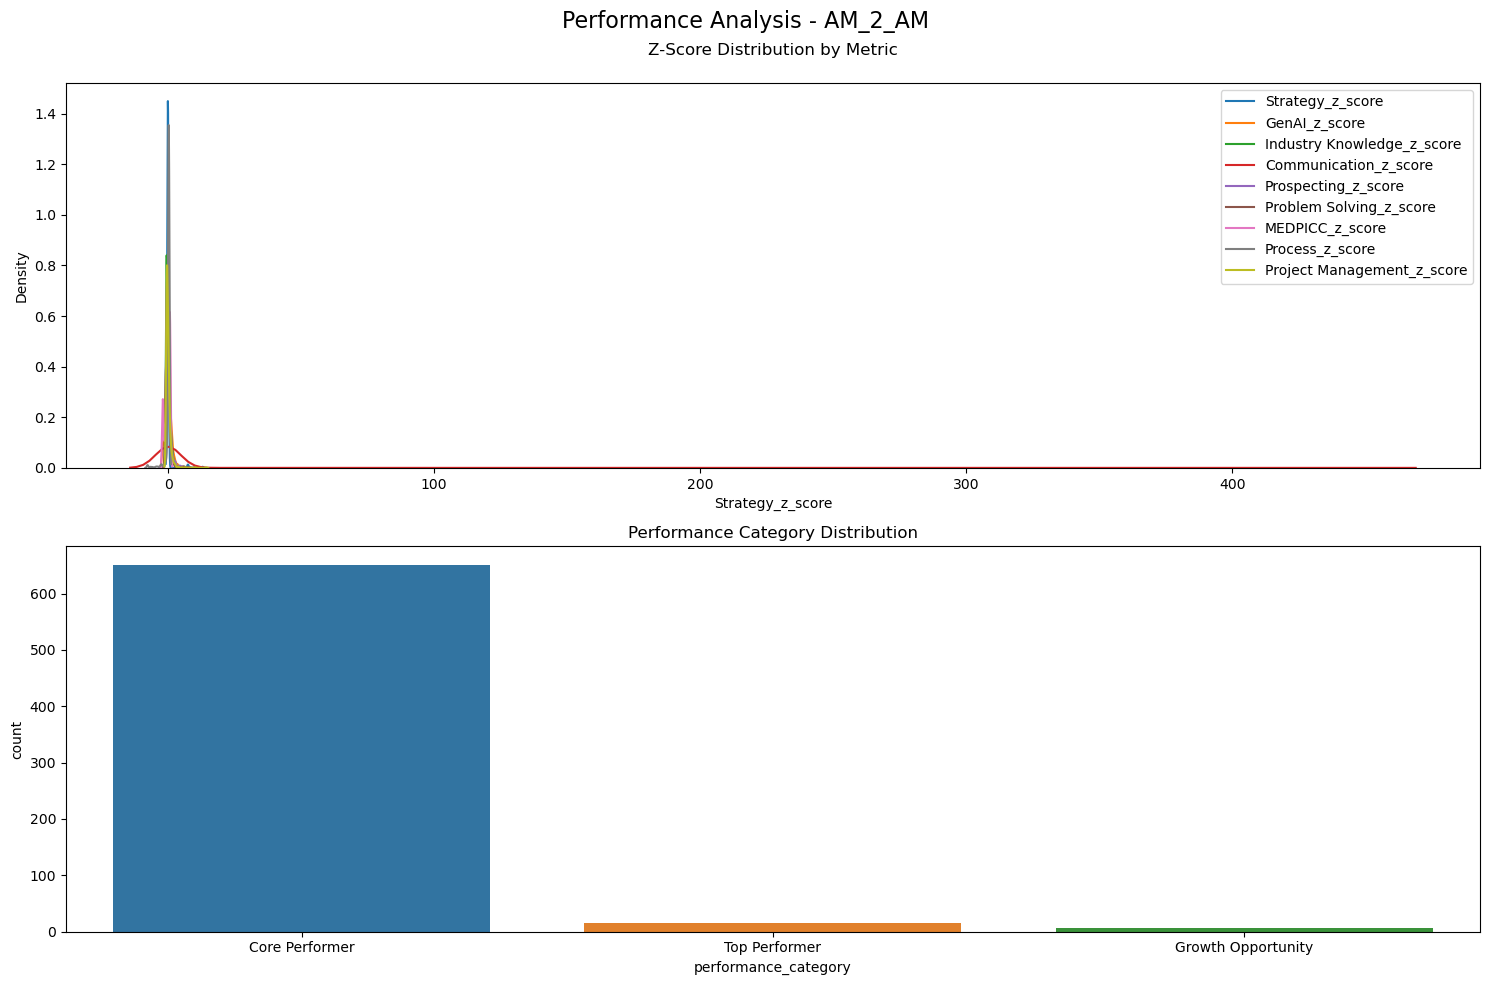

Results exported to: z_scores_original/results_AM_2_AM.csv
--------------------------------------------------------------------------------

Processing AM_3_AM.csv...

Transformation Summary:
Strategy:
  Skewness: 8.904
  Transformation: Signed square root
GenAI:
  Skewness: 0.930
  Transformation: Modified z-score
Industry Knowledge:
  Skewness: 22.141
  Transformation: Signed square root
Communication:
  Skewness: nan
  Transformation: Modified z-score (heavy skew)
Prospecting:
  Skewness: 3.682
  Transformation: Signed square root
Problem Solving:
  Skewness: 23.265
  Transformation: Signed square root
MEDPICC:
  Skewness: -0.166
  Transformation: Standard
Process:
  Skewness: -3.549
  Transformation: Square
Project Management:
  Skewness: 34.841
  Transformation: Signed square root

Summary Statistics for AM_3_AM:
             emplid  Cluster  job_lvl_sort     Strategy        GenAI  \
count  2.132000e+03   2132.0   2132.000000  2132.000000  2132.000000   
mean   1.107565e+08      3

C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be rem

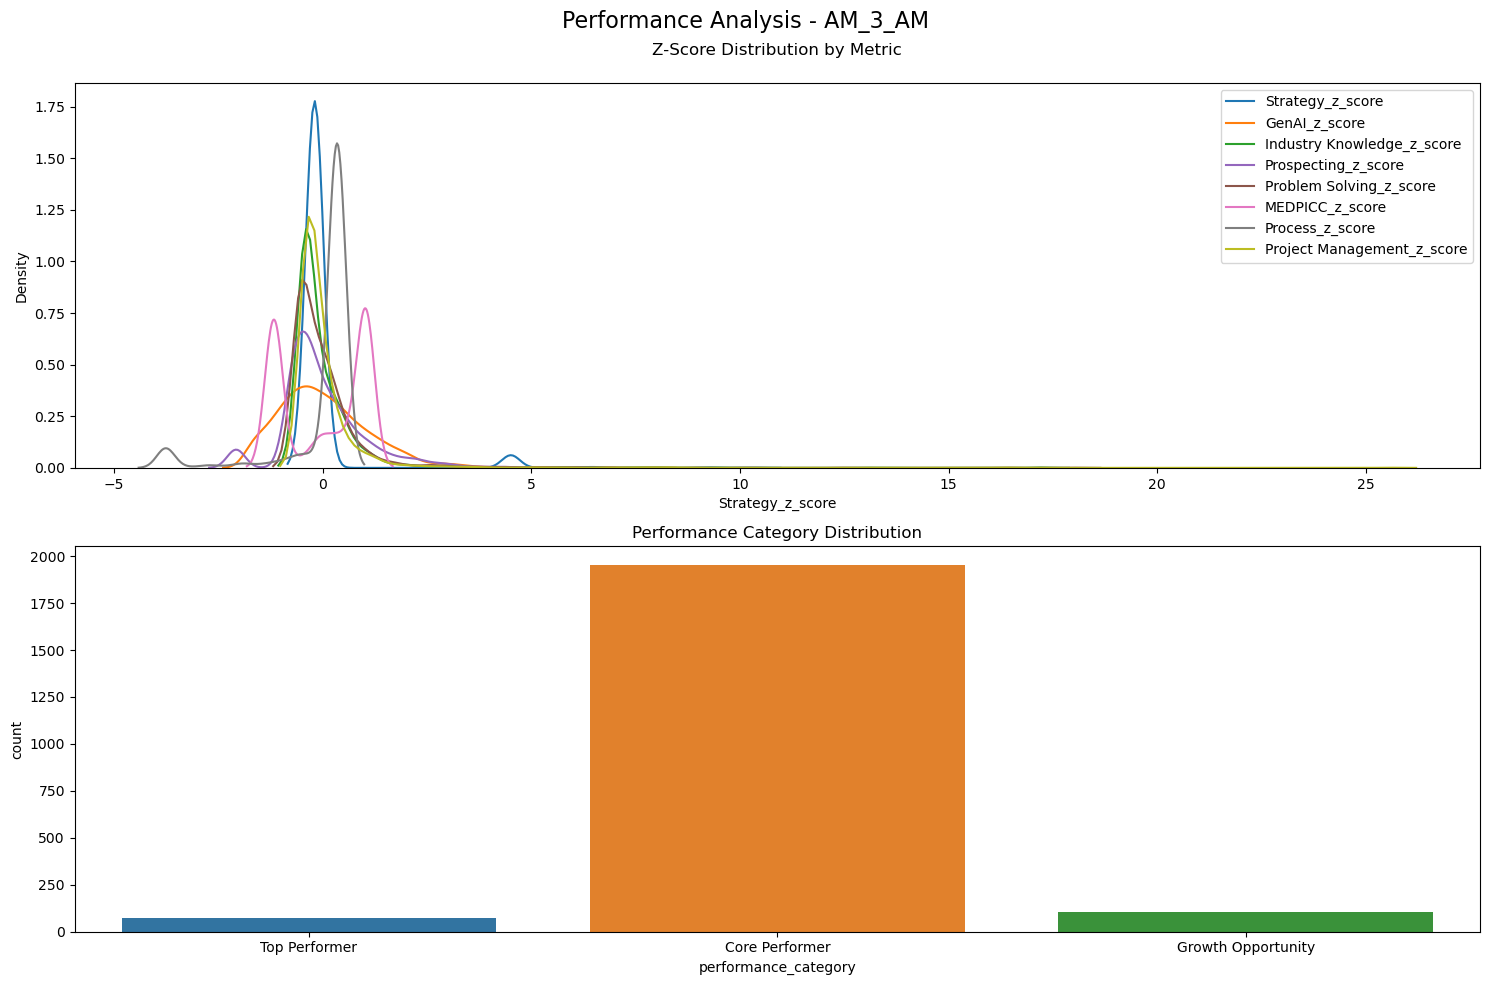

Results exported to: z_scores_original/results_AM_3_AM.csv
--------------------------------------------------------------------------------

Processing DGR_0_DGR.csv...

Transformation Summary:
Executive POV:
  Skewness: 15.232
  Transformation: Modified z-score (heavy skew)
Prospecting:
  Skewness: 2.080
  Transformation: Signed square root
MEDPICC:
  Skewness: -0.447
  Transformation: Standard
Lead Management:
  Skewness: 4.803
  Transformation: Signed square root
GenAI:
  Skewness: 5.336
  Transformation: Signed square root
Collaboration:
  Skewness: -0.130
  Transformation: Standard

Summary Statistics for DGR_0_DGR:
             emplid  Cluster  job_lvl_sort  Executive POV  Prospecting  \
count  2.350000e+02    235.0    235.000000     235.000000   235.000000   
mean   1.308483e+08      0.0      4.195745       0.000043    22.907745   
std    3.759576e+07      0.0      0.397620       0.000652    23.022096   
min    1.007160e+08      0.0      4.000000       0.000000     0.000000   
2

C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be rem

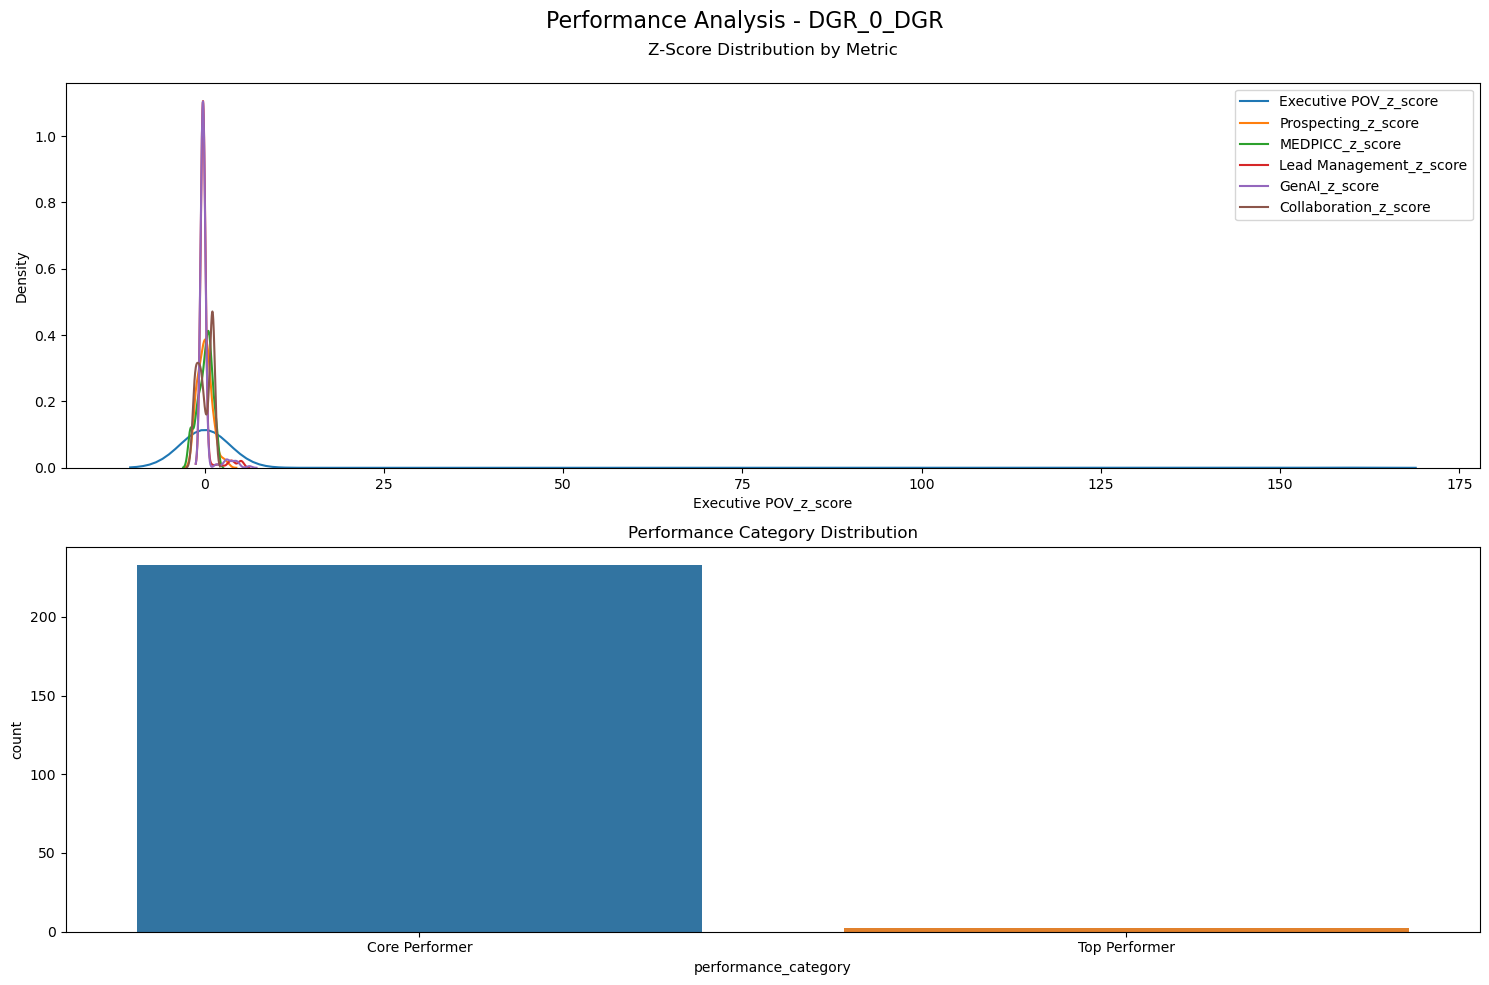

Results exported to: z_scores_original/results_DGR_0_DGR.csv
--------------------------------------------------------------------------------

Processing DGR_1_DGR.csv...

Transformation Summary:
Executive POV:
  Skewness: 21.726
  Transformation: Modified z-score (heavy skew)
Prospecting:
  Skewness: 1.952
  Transformation: Signed square root
MEDPICC:
  Skewness: -0.881
  Transformation: Modified z-score
Lead Management:
  Skewness: 21.726
  Transformation: Signed square root
GenAI:
  Skewness: 21.726
  Transformation: Modified z-score (heavy skew)
Collaboration:
  Skewness: 0.144
  Transformation: Standard

Summary Statistics for DGR_1_DGR:
             emplid  Cluster  job_lvl_sort  Executive POV  Prospecting  \
count  4.750000e+02    475.0    475.000000     475.000000   475.000000   
mean   1.913873e+08      1.0      4.023158       0.000021    27.132821   
std    3.191454e+07      0.0      0.187956       0.000459    25.590163   
min    1.016300e+08      1.0      4.000000       0.00

C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be rem

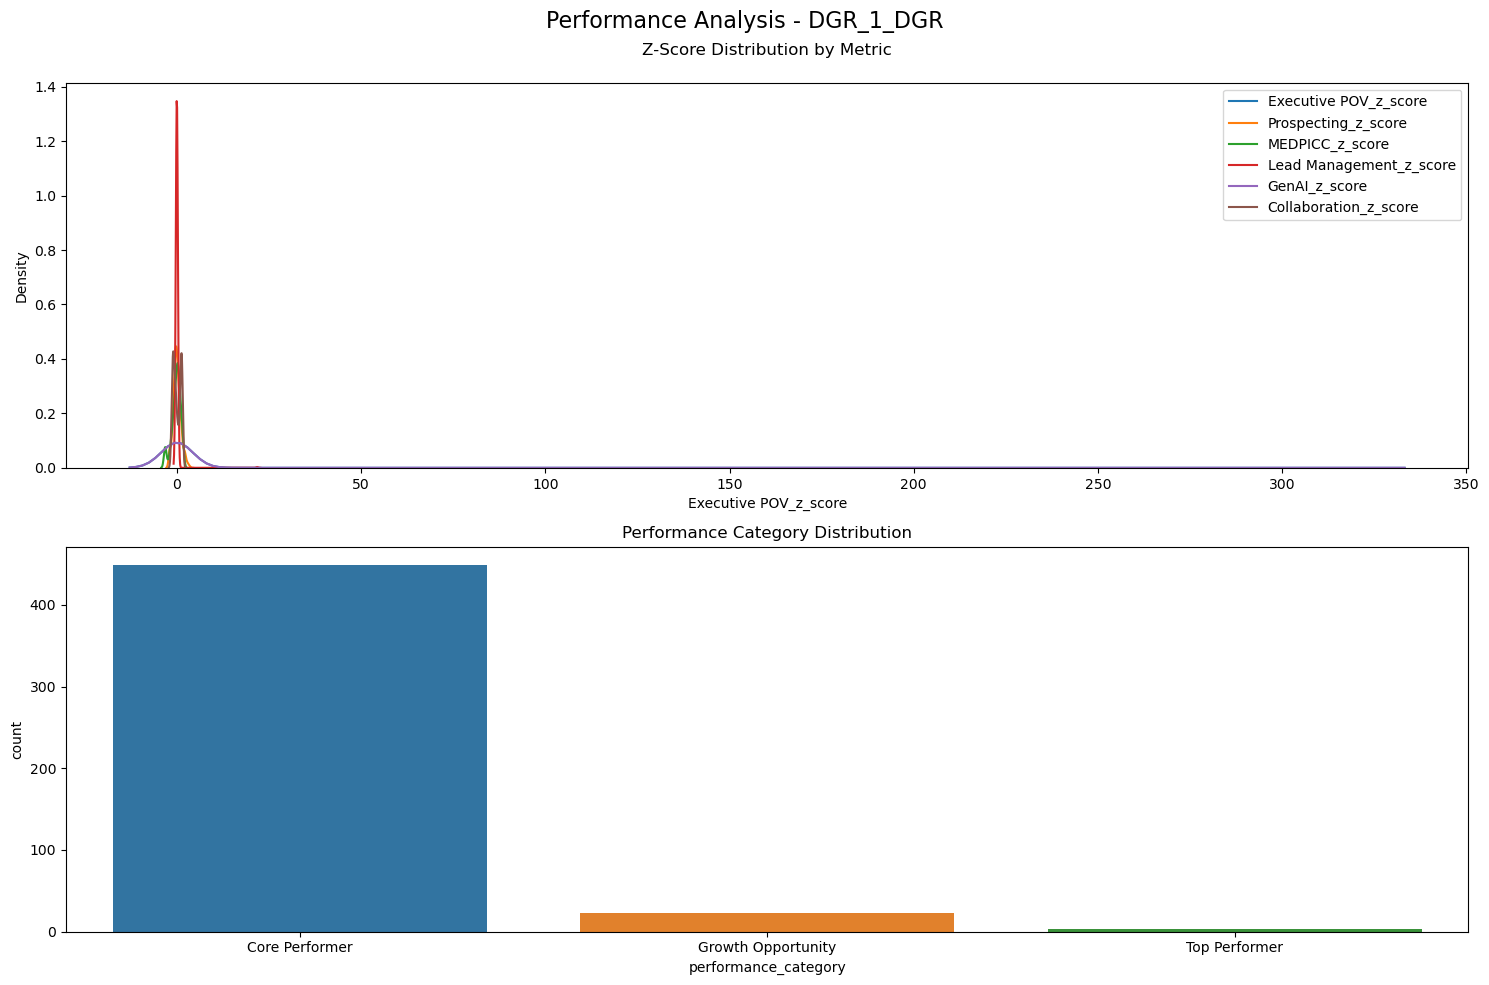

Results exported to: z_scores_original/results_DGR_1_DGR.csv
--------------------------------------------------------------------------------

Processing DGR_2_DGR.csv...

Transformation Summary:
Executive POV:
  Skewness: nan
  Transformation: Modified z-score (heavy skew)
Prospecting:
  Skewness: 1.964
  Transformation: Signed square root
MEDPICC:
  Skewness: -0.465
  Transformation: Standard
Lead Management:
  Skewness: 5.996
  Transformation: Signed square root
GenAI:
  Skewness: 8.611
  Transformation: Signed square root
Collaboration:
  Skewness: -0.045
  Transformation: Standard

Summary Statistics for DGR_2_DGR:
             emplid  Cluster  job_lvl_sort  Executive POV  Prospecting  \
count  1.190000e+02    119.0    119.000000          119.0   119.000000   
mean   1.704892e+08      2.0      4.067227            0.0    32.144538   
std    4.452424e+07      0.0      0.251473            0.0    28.175623   
min    1.001499e+08      2.0      4.000000            0.0     0.000000   
25

C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\Temp\ipykernel_41992\3035844135.py:155: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=self.df[col], label=col)
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN

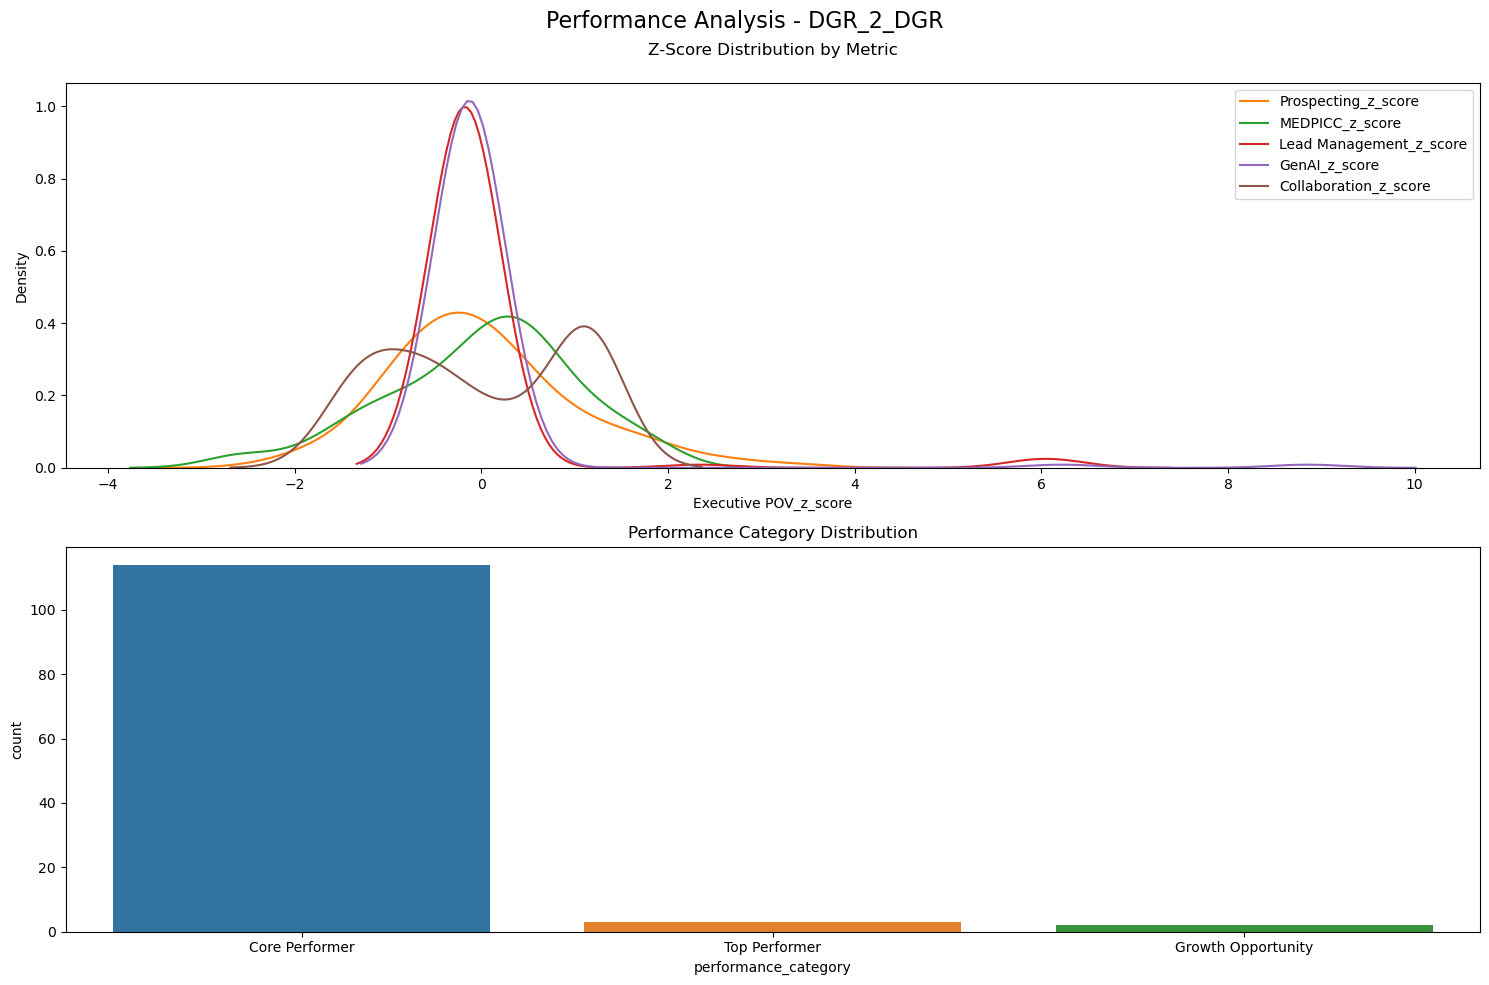

Results exported to: z_scores_original/results_DGR_2_DGR.csv
--------------------------------------------------------------------------------

Processing DGR_3_DGR.csv...

Transformation Summary:
Executive POV:
  Skewness: nan
  Transformation: Modified z-score (heavy skew)
Prospecting:
  Skewness: 1.631
  Transformation: Signed square root
MEDPICC:
  Skewness: 0.619
  Transformation: Modified z-score
Lead Management:
  Skewness: 5.972
  Transformation: Signed square root
GenAI:
  Skewness: 3.910
  Transformation: Signed square root
Collaboration:
  Skewness: 0.618
  Transformation: Modified z-score

Summary Statistics for DGR_3_DGR:
             emplid  Cluster  job_lvl_sort  Executive POV  Prospecting  \
count  6.800000e+01     68.0     68.000000           68.0    68.000000   
mean   1.186442e+08      3.0      4.161765            0.0    31.355882   
std    2.639573e+07      0.0      0.370973            0.0    35.831020   
min    1.001959e+08      3.0      4.000000            0.0     

C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\Temp\ipykernel_41992\3035844135.py:155: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=self.df[col], label=col)
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN

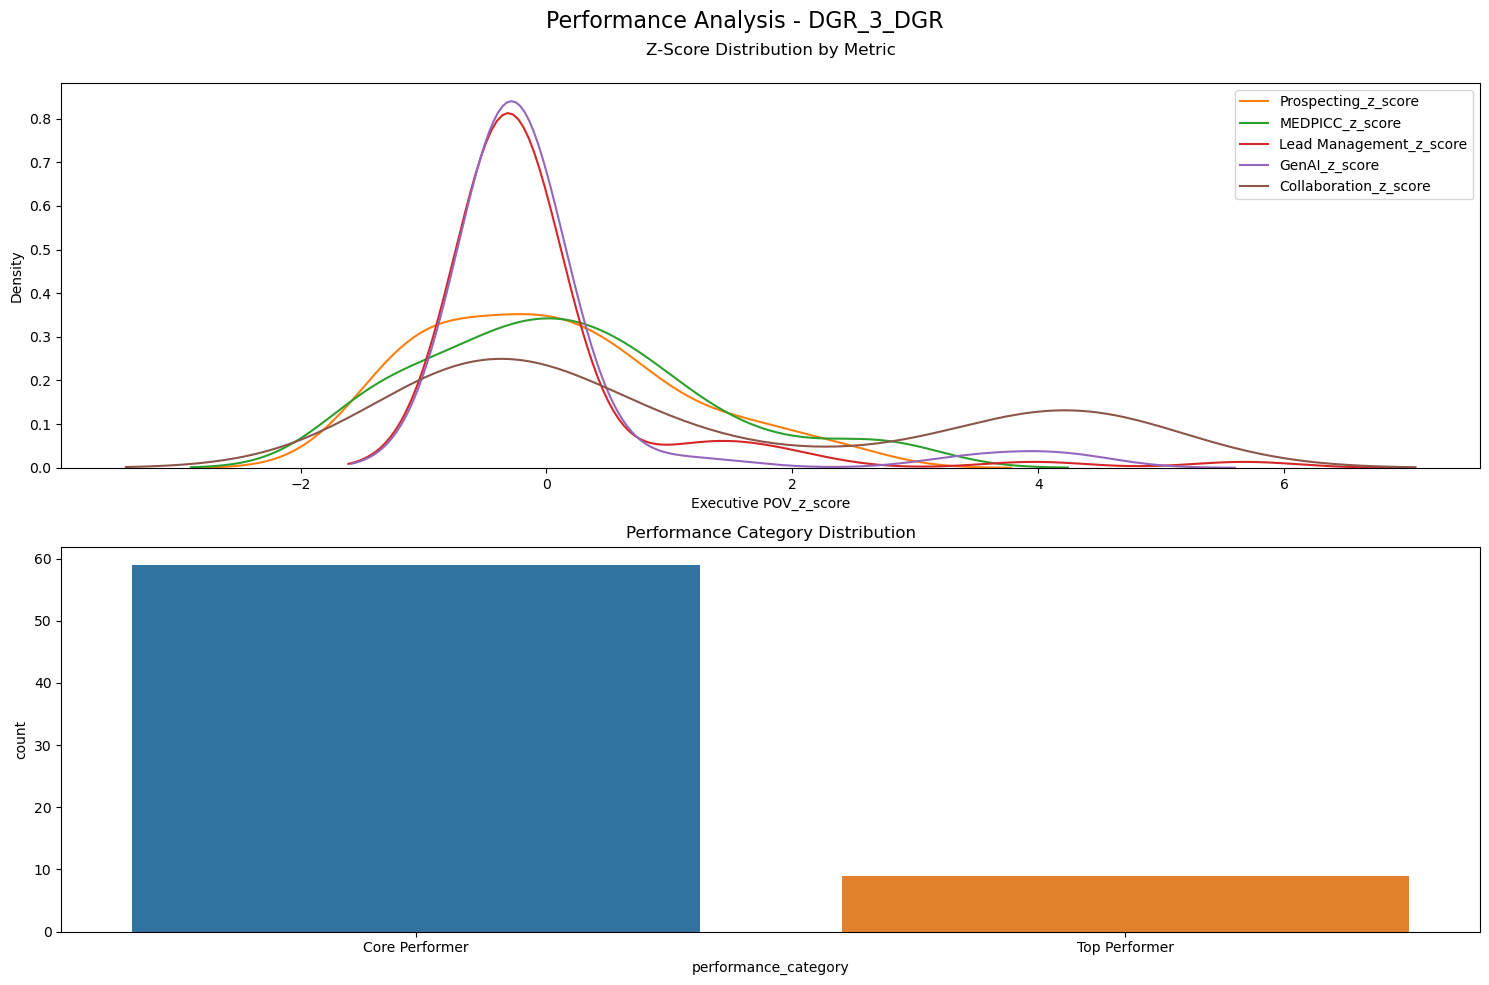

Results exported to: z_scores_original/results_DGR_3_DGR.csv
--------------------------------------------------------------------------------

Processing ISR_0_ISR.csv...

Transformation Summary:
Prospecting:
  Skewness: 3.435
  Transformation: Log
GenAI:
  Skewness: 0.306
  Transformation: Standard
Account Management:
  Skewness: nan
  Transformation: Modified z-score (heavy skew)
MEDPICC:
  Skewness: -0.347
  Transformation: Standard
Technology:
  Skewness: 9.596
  Transformation: Signed square root
Sales Skills:
  Skewness: 4.416
  Transformation: Signed square root
Customer Engagement:
  Skewness: 14.057
  Transformation: Signed square root

Summary Statistics for ISR_0_ISR:
             emplid  Cluster  job_lvl_sort  Prospecting       GenAI  \
count  2.230000e+02    223.0    223.000000   223.000000  223.000000   
mean   1.114792e+08      0.0      4.551570     1.522915    8.735426   
std    1.105941e+07      0.0      0.541756     0.690347    3.607668   
min    1.017701e+08      0.0

C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\Temp\ipykernel_41992\3035844135.py:155: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_sing

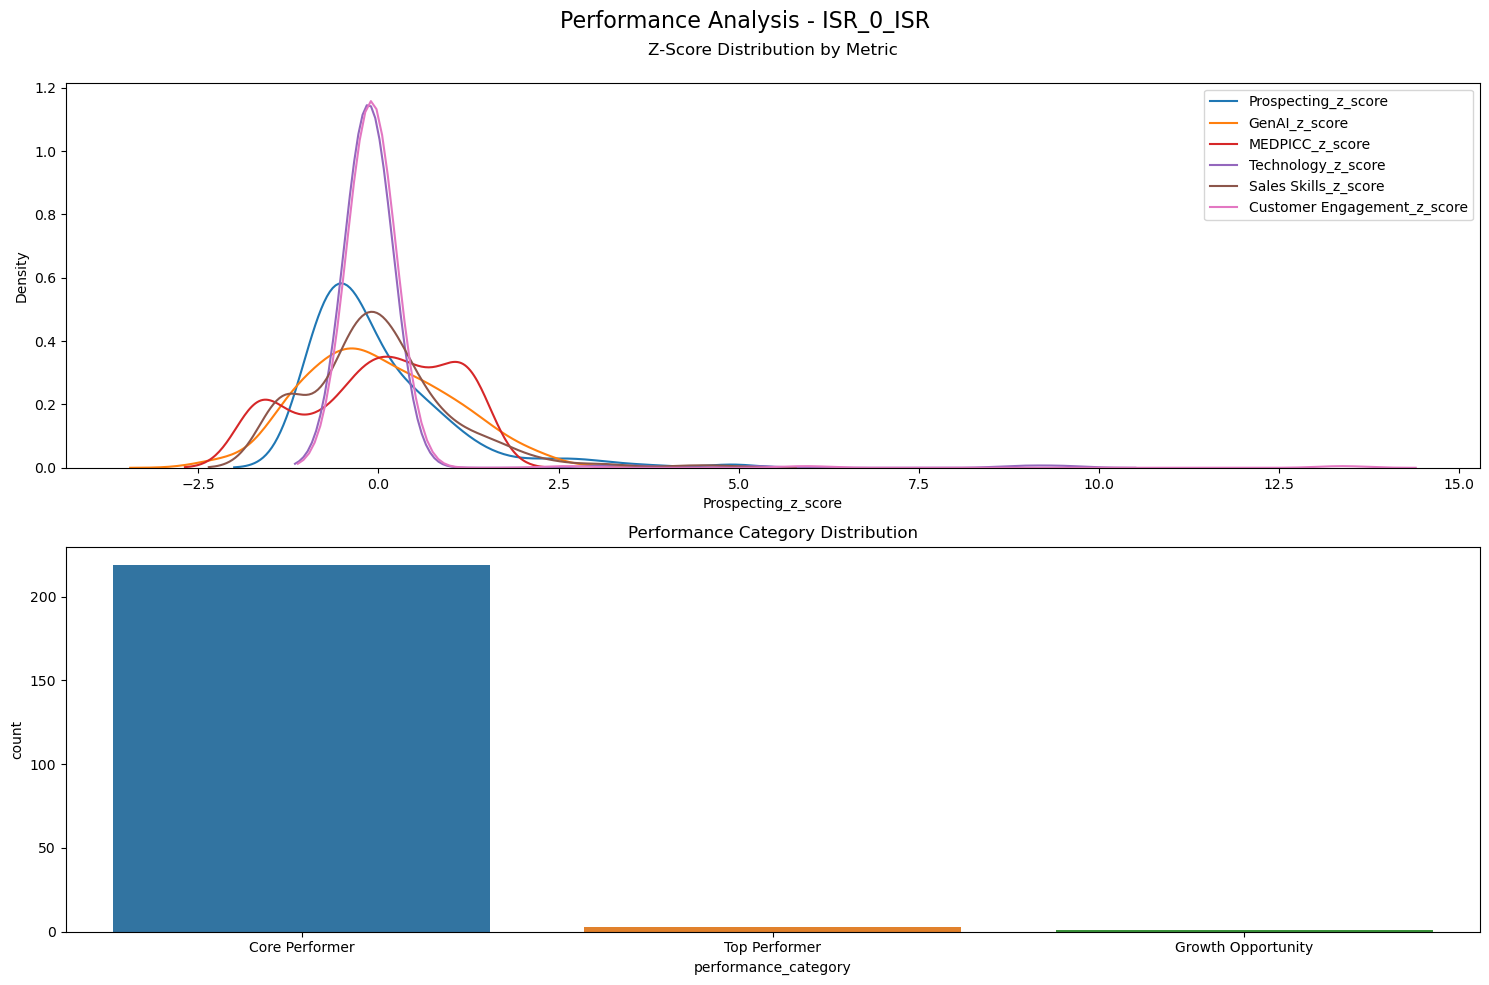

Results exported to: z_scores_original/results_ISR_0_ISR.csv
--------------------------------------------------------------------------------

Processing ISR_1_ISR.csv...

Transformation Summary:
Prospecting:
  Skewness: 10.707
  Transformation: Signed square root
GenAI:
  Skewness: 0.906
  Transformation: Modified z-score
Account Management:
  Skewness: 18.358
  Transformation: Modified z-score (heavy skew)
MEDPICC:
  Skewness: 0.080
  Transformation: Standard
Technology:
  Skewness: 15.567
  Transformation: Signed square root
Sales Skills:
  Skewness: 12.770
  Transformation: Signed square root
Customer Engagement:
  Skewness: 20.659
  Transformation: Signed square root

Summary Statistics for ISR_1_ISR:
             emplid  Cluster  job_lvl_sort  Prospecting       GenAI  \
count  6.800000e+02    680.0    680.000000   680.000000  680.000000   
mean   1.097388e+08      1.0      4.892647     1.739191    6.516176   
std    7.283578e+06      0.0      0.578408     1.726493    3.723868   


C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be rem

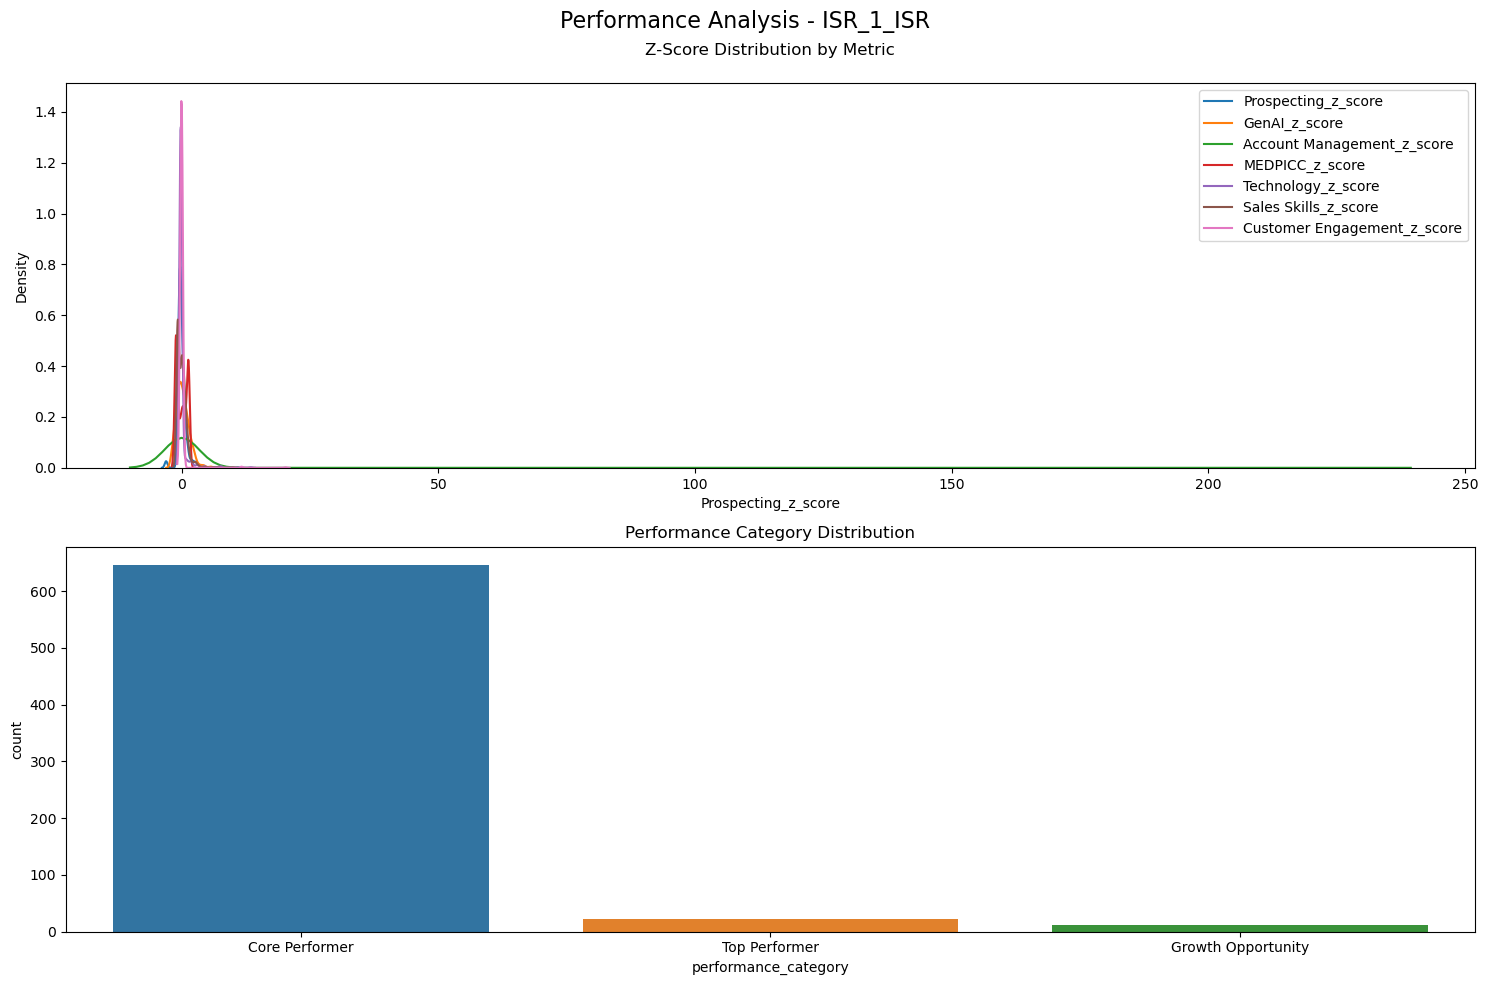

Results exported to: z_scores_original/results_ISR_1_ISR.csv
--------------------------------------------------------------------------------

Processing ISR_2_ISR.csv...

Transformation Summary:
Prospecting:
  Skewness: 5.284
  Transformation: Signed square root
GenAI:
  Skewness: 0.810
  Transformation: Modified z-score
Account Management:
  Skewness: 8.964
  Transformation: Modified z-score (heavy skew)
MEDPICC:
  Skewness: 0.317
  Transformation: Standard
Technology:
  Skewness: 9.138
  Transformation: Signed square root
Sales Skills:
  Skewness: 6.440
  Transformation: Signed square root
Customer Engagement:
  Skewness: nan
  Transformation: Modified z-score (heavy skew)

Summary Statistics for ISR_2_ISR:
             emplid  Cluster  job_lvl_sort  Prospecting       GenAI  \
count  2.500000e+02    250.0    250.000000   250.000000  250.000000   
mean   1.433358e+08      2.0      4.904000     1.466080    6.684000   
std    4.712789e+07      0.0      0.586652     1.196598    4.475743

C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\methvenr\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be rem

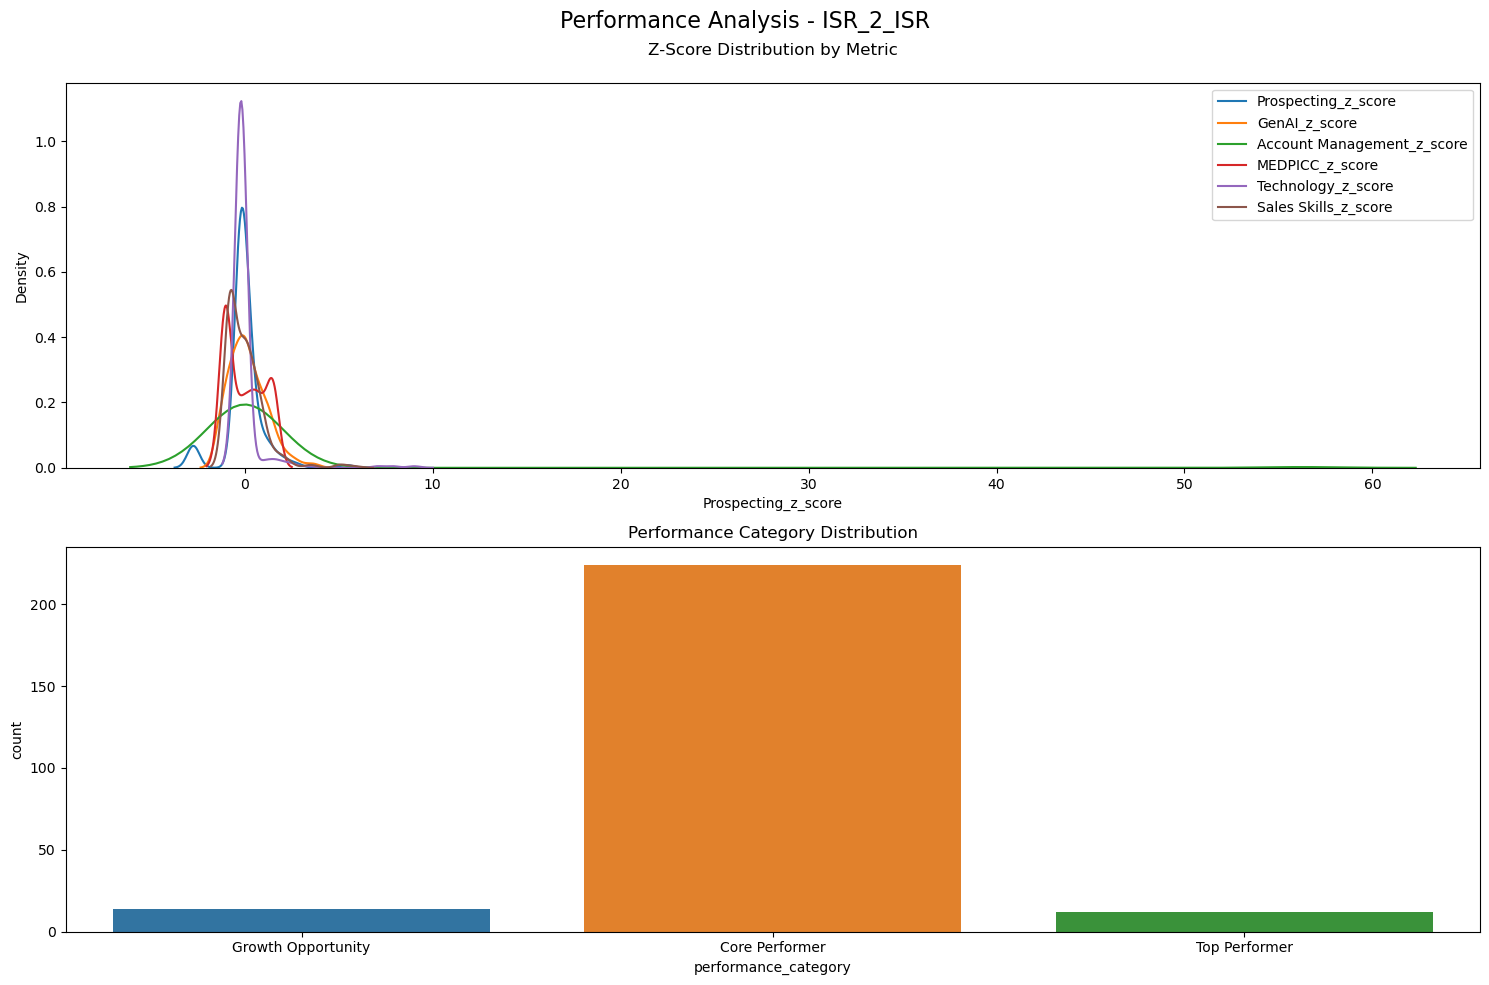

Results exported to: z_scores_original/results_ISR_2_ISR.csv
--------------------------------------------------------------------------------


In [13]:
# Get list of all CSV files in benchmarking folder
benchmark_folder = 'benchmarking'
csv_files = [f for f in os.listdir(benchmark_folder) if f.endswith('.csv')]

# Process each CSV file
for csv_file in csv_files:
    print(f"\nProcessing {csv_file}...")

    # Construct full file path
    file_path = os.path.join(benchmark_folder, csv_file)
    
    # Read CSV into dataframe
    df = pd.read_csv(file_path)

    # Define fields to exclude
    fields_to_exclude = ['emplid', 'custom_smsrole', 'Cluster','tenure','geo','segment','job_lvl_sort']

    # Get column names excluding specified fields
    metrics_to_analyze = [col for col in df.columns if col not in fields_to_exclude]
    
    # Initialize benchmarking
    benchmark = SalesPerformanceBenchmark()
    
    # Load data
    file_path = os.path.join(benchmark_folder, csv_file)
    benchmark.load_data(file_path)
    
    # Calculate z-scores
    benchmark.calculate_z_scores(metrics_to_analyze)
    
    # Categorize performance
    benchmark.categorize_performance(z_score_threshold=1)
    
    # Generate summary statistics
    summary = benchmark.generate_summary_stats()
    
    # Create output filename based on input filename
    output_basename = os.path.splitext(csv_file)[0]  # Remove .csv extension
    
    print(f"\nSummary Statistics for {output_basename}:")
    print(summary['basic_stats'])
    print(f"\nPerformance Category Distribution for {output_basename}:")
    print(summary['category_distribution'])
    
    # Visualize results with optional title
    benchmark.visualize_performance(title=f"Performance Analysis - {output_basename}")
    
    # Export results with original filename incorporated
    output_filename = f'z_scores_original/results_{output_basename}.csv'
    benchmark.export_results(output_filename)
    print(f"Results exported to: {output_filename}")
    
    print("-" * 80)  # Separator between files

## Scale z-score output

In [14]:
import pandas as pd
import numpy as np
from pathlib import Path

# Create directories if they don't exist
input_dir = Path('z_scores_original')
output_dir = Path('z_scores_scaled')
output_dir.mkdir(exist_ok=True)

# List to store all dataframes
all_dfs = []

try:
    # Process each CSV file in the benchmarking folder
    for file in input_dir.glob('*.csv'):
        # Read CSV file
        df = pd.read_csv(file)
        
        # Find columns containing '_z_score'
        z_score_cols = [col for col in df.columns if '_z_score' in col.lower()]
        
        if z_score_cols:
            # Calculate percentiles for z-score columns
            for col in z_score_cols:
                # Add percentile column
                percentile_col = f"{col}_percentile"
                df[percentile_col] = df[col].rank(pct=True, na_option='keep') * 100
                
                # Calculate quartiles with handling for duplicate values and NaNs
                quartile_col = f"{col}_quartile"
                
                # Check if the column has any non-NaN values
                if df[col].notna().any():
                    try:
                        df[quartile_col] = pd.qcut(df[col].fillna(df[col].mean()), 
                                                   q=4, 
                                                   labels=['Q1', 'Q2', 'Q3', 'Q4'])
                    except ValueError:
                        # If qcut fails due to duplicate values, use cut instead
                        df[quartile_col] = pd.cut(df[col].fillna(df[col].mean()), 
                                                  bins=4, 
                                                  labels=['Q1', 'Q2', 'Q3', 'Q4'])
                else:
                    # If all values are NaN, assign 'Unknown' to all rows
                    df[quartile_col] = 'Unknown'
        
            # Export processed file to z_scores folder
            output_file = output_dir / f"processed_{file.name}"
            df.to_csv(output_file, index=False)
            
            # Add to list of dataframes
            all_dfs.append(df)
            
            # Print z-score fields found in this file
            print(f"\nFile: {file.name}")
            print("Z-score fields found:", z_score_cols)

    if all_dfs:
        # Combine all dataframes
        # Using outer join to keep all columns from all dataframes
        combined_df = pd.concat(all_dfs, axis=0, ignore_index=True, join='outer')
        
        # Export combined dataframe
        combined_output = output_dir / "combined_z_scores.csv"
        combined_df['cluster_name'] = combined_df['custom_smsrole'].astype(str) + '_' + combined_df['Cluster'].astype(str)
        combined_df.to_csv(combined_output, index=False)
        
        print(f"\nResults exported to {output_dir}")
        print(f"Combined file created: {combined_output}")
        
    else:
        print("No z-score fields found in any CSV files")

except Exception as e:
    print(f"An error occurred: {str(e)}")



File: results_AM_0_AM.csv
Z-score fields found: ['Strategy_z_score', 'GenAI_z_score', 'Industry Knowledge_z_score', 'Communication_z_score', 'Prospecting_z_score', 'Problem Solving_z_score', 'MEDPICC_z_score', 'Process_z_score', 'Project Management_z_score']

File: results_AM_1_AM.csv
Z-score fields found: ['Strategy_z_score', 'GenAI_z_score', 'Industry Knowledge_z_score', 'Communication_z_score', 'Prospecting_z_score', 'Problem Solving_z_score', 'MEDPICC_z_score', 'Process_z_score', 'Project Management_z_score']

File: results_AM_2_AM.csv
Z-score fields found: ['Strategy_z_score', 'GenAI_z_score', 'Industry Knowledge_z_score', 'Communication_z_score', 'Prospecting_z_score', 'Problem Solving_z_score', 'MEDPICC_z_score', 'Process_z_score', 'Project Management_z_score']

File: results_AM_3_AM.csv
Z-score fields found: ['Strategy_z_score', 'GenAI_z_score', 'Industry Knowledge_z_score', 'Communication_z_score', 'Prospecting_z_score', 'Problem Solving_z_score', 'MEDPICC_z_score', 'Process_

In [15]:
# Get list of columns with 'percentile' in the name
percentile_cols = [col for col in combined_df.columns if 'percentile' in col.lower()]

# Create new dataframe with emplid and percentile columns
percentile_df = combined_df[['emplid','cluster_name','segment'] + percentile_cols]

# Display first few rows
print(percentile_df.head())

# If you want to see all column names
print("\nSelected columns:")
print(percentile_df.columns.tolist())

# If you want to save to a new CSV file
percentile_df.to_csv('z_scores_scaled/percentile_scores.csv', index=False)


   emplid cluster_name                            segment  \
0   55852         AM_0                   Enterprise (ENT)   
1  250802         AM_0                   Enterprise (ENT)   
2  337216         AM_0      Digital Native Business (DNB)   
3  388891         AM_0  Independent Software Vendor (ISV)   
4  419805         AM_0                   Enterprise (ENT)   

   Strategy_z_score_percentile  GenAI_z_score_percentile  \
0                    48.886986                 10.844749   
1                    48.886986                 35.987443   
2                    48.886986                 63.898402   
3                    48.886986                 63.898402   
4                    48.886986                 35.987443   

   Industry Knowledge_z_score_percentile  Communication_z_score_percentile  \
0                              34.446347                              50.0   
1                              34.446347                              50.0   
2                              98.8869

In [16]:
# Transpose Results for export

# Define the columns to keep as is
id_columns = ['emplid', 'Cluster', 'tenure', 'geo', 'segment', 'job_lvl_sort','custom_smsrole','performance_category']

# Melt the dataframe
melted_df = pd.melt(combined_df, id_vars=id_columns, var_name='attribute', value_name='value')

# Sort the result by emplid for clarity
melted_df = melted_df.sort_values(id_columns)

# Reset the index
melted_df = melted_df.reset_index(drop=True)

# Display the first few rows of the result
print(melted_df.head(10))

# Optionally, save the result to a new CSV file
melted_df.to_csv('z_scores_scaled/transposed_combined_z_scores.csv', index=False)


   emplid  Cluster   tenure    geo           segment  job_lvl_sort  \
0   23354        3  5 Years  NAMER  Enterprise (ENT)             7   
1   23354        3  5 Years  NAMER  Enterprise (ENT)             7   
2   23354        3  5 Years  NAMER  Enterprise (ENT)             7   
3   23354        3  5 Years  NAMER  Enterprise (ENT)             7   
4   23354        3  5 Years  NAMER  Enterprise (ENT)             7   
5   23354        3  5 Years  NAMER  Enterprise (ENT)             7   
6   23354        3  5 Years  NAMER  Enterprise (ENT)             7   
7   23354        3  5 Years  NAMER  Enterprise (ENT)             7   
8   23354        3  5 Years  NAMER  Enterprise (ENT)             7   
9   23354        3  5 Years  NAMER  Enterprise (ENT)             7   

  custom_smsrole performance_category           attribute     value  
0             AM        Top Performer            Strategy       0.0  
1             AM        Top Performer               GenAI       7.0  
2             AM   

## Periodic Analysis

In [ ]:
# Additional function for periodic analysis
def run_periodic_analysis(data_file, period='monthly'):
    """
    Run analysis for specific time periods
    """
    df = pd.read_csv(data_file)
    df['date'] = pd.to_datetime(df['date'])
    
    if period == 'monthly':
        grouped = df.groupby(df['date'].dt.to_period('M'))
    elif period == 'quarterly':
        grouped = df.groupby(df['date'].dt.to_period('Q'))
    
    period_results = []
    
    for period, group in grouped:
        benchmark = SalesPerformanceBenchmark()
        benchmark.df = group
        metrics = ['revenue', 'deals_closed', 'win_rate', 'customer_satisfaction']
        benchmark.calculate_z_scores(metrics)
        benchmark.categorize_performance()
        
        period_results.append({
            'period': period,
            'summary': benchmark.generate_summary_stats()
        })
    
    return period_results

In [ ]:
# Prepare your data CSV with columns:
sales_rep, revenue, deals_closed, win_rate, customer_satisfaction

In [ ]:
# Run the analysis:
benchmark = SalesPerformanceBenchmark()
benchmark.load_data('your_data.csv')
benchmark.calculate_z_scores(['revenue', 'deals_closed', 'win_rate', 'customer_satisfaction'])
benchmark.categorize_performance()

In [ ]:
# For periodic analysis:
results = run_periodic_analysis('your_data.csv', period='monthly')

## Treat for Skewness

In [ ]:
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def analyze_and_transform_data(data):
    """
    Analyzes data skewness and returns appropriate z-scores
    """
    # Calculate skewness
    skewness = stats.skew(data)
    
    # Create initial visualization
    plt.figure(figsize=(12, 4))
    
    plt.subplot(121)
    sns.histplot(data, kde=True)
    plt.title(f'Original Distribution\nSkewness: {skewness:.2f}')
    
    # Function to calculate modified z-scores (median-based)
    def modified_zscore(x):
        median = np.median(x)
        mad = stats.median_abs_deviation(x)
        if mad == 0:
            mad = np.mean(abs(x - median))  # Alternative if MAD is zero
        return 0.6745 * (x - median) / mad
    
    # Function to calculate traditional z-scores
    def standard_zscore(x):
        return stats.zscore(x)
    
    # Initialize variables
    transformed_data = data.copy()
    transformation_used = "None"
    z_scores = None
    
    # Decision logic based on skewness
    if abs(skewness) < 0.5:
        # Data is approximately symmetric
        z_scores = standard_zscore(data)
        transformation_used = "Standard z-score (approximately normal)"
        
    elif abs(skewness) >= 0.5 and abs(skewness) < 1:
        # Moderately skewed - use modified z-scores
        z_scores = modified_zscore(data)
        transformation_used = "Modified z-score (moderately skewed)"
        
    else:
        # Heavily skewed - try transformations
        if skewness > 0:  # Right-skewed
            # Try log transformation if all values are positive
            if np.all(data > 0):
                transformed_data = np.log(data)
                transformation_used = "Log transformation"
            # If negative values exist, try square root of absolute values
            else:
                transformed_data = np.sign(data) * np.sqrt(np.abs(data))
                transformation_used = "Signed square root transformation"
        else:  # Left-skewed
            # Try square transformation
            transformed_data = np.sign(data) * (np.abs(data) ** 2)
            transformation_used = "Square transformation"
        
        # Calculate skewness after transformation
        new_skewness = stats.skew(transformed_data)
        
        # If transformation helped, use standard z-scores on transformed data
        # If not, use modified z-scores on original data
        if abs(new_skewness) < abs(skewness):
            z_scores = standard_zscore(transformed_data)
        else:
            z_scores = modified_zscore(data)
            transformation_used = "Modified z-score (heavily skewed)"
    
    # Plot transformed data
    plt.subplot(122)
    sns.histplot(z_scores, kde=True)
    plt.title(f'Z-Scores Distribution\nTransformation: {transformation_used}')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'original_skewness': skewness,
        'transformation_used': transformation_used,
        'z_scores': z_scores
    }

In [ ]:
# Example usage
def generate_example_data():
    # Generate some sample skewed data
    np.random.seed(42)
    normal_data = np.random.normal(loc=10, scale=2, size=1000)
    skewed_component = np.random.exponential(scale=2, size=1000)
    skewed_data = normal_data + skewed_component
    return skewed_data

# Run the analysis
data = generate_example_data()
results = analyze_and_transform_data(data)

# Print results
print(f"\nOriginal Data Skewness: {results['original_skewness']:.2f}")
print(f"Transformation Used: {results['transformation_used']}")
print("\nFirst few z-scores:", results['z_scores'][:5])

# Basic statistics of z-scores
z_scores_stats = pd.Series(results['z_scores']).describe()
print("\nZ-scores statistics:")
print(z_scores_stats)